In [3]:

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter
from scipy.optimize import minimize, curve_fit
from scipy.signal import find_peaks, savgol_filter
import warnings
from tqdm.auto import tqdm

plt.style.use('default')

In [4]:
# 1. Load the data
file_path = r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl'
try:
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    df = data['data']
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Data file not found. Please check path.")

# Extract just SST and SSL
df_all_years = df.copy()
df_all_years['week'] = df_all_years.index.isocalendar().week

products = ['sst', 'ssl']
weekly_data = {p: [] for p in products}

for week_num, week_df in tqdm(df_all_years.groupby('week'), desc="Processing weeks"):
    for p in products:
        grids = []
        for _, row in week_df.iterrows():
            grid = row.get(p)
            if grid is not None and not (isinstance(grid, float) and np.isnan(grid)):
                grid_arr = np.array(grid, dtype=float)
                if not np.isnan(grid_arr).all():
                    grids.append(grid_arr)
        
        if grids:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', category=RuntimeWarning)
                avg_grid = np.nanmean(np.stack(grids), axis=0)
                values = avg_grid.flatten()
                values = values[~np.isnan(values)]
                
                if len(values) > 0:
                    for val in values:
                        weekly_data[p].append({'week': week_num, 'value': val})

for p in products:
    weekly_data[p] = pd.DataFrame(weekly_data[p])

Data loaded successfully.


Processing weeks:   0%|          | 0/53 [00:00<?, ?it/s]

In [5]:
# Function to create the density map (2D Histogram)
def get_density_map(df_p, y_bins_count=100):
    x_bins = np.arange(1, 54) - 0.5
    range_y = [df_p['value'].min(), df_p['value'].max()]
    
    h, xedges, yedges = np.histogram2d(
        df_p['week'], df_p['value'],
        bins=[x_bins, y_bins_count],
        range=[[0.5, 52.5], range_y]
    )
    
    # Store bin centers for plotting/fitting
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    
    return h, x_centers, y_centers

## SST: Nonlinear Least Squares with Nearest-Neighbor Loss (Two Curves)
We fit two seasonal curves simultaneously by minimizing the distance of every data point to the *closest* of the two curves.

In [6]:
df_sst = weekly_data['sst']
h_sst, x_sst, y_sst = get_density_map(df_sst, y_bins_count=100)

# Extract raw points from the dataframe to fit easily
weeks_raw = df_sst['week'].values
sst_raw = df_sst['value'].values

def season_curve(x, A, phase, offset):
    # Standard 1st order Fourier / Sine wave
    return A * np.sin(2 * np.pi * x / 52.0 + phase) + offset


C:\Users\Makai\AppData\Local\Temp\ipykernel_81480\2103973016.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


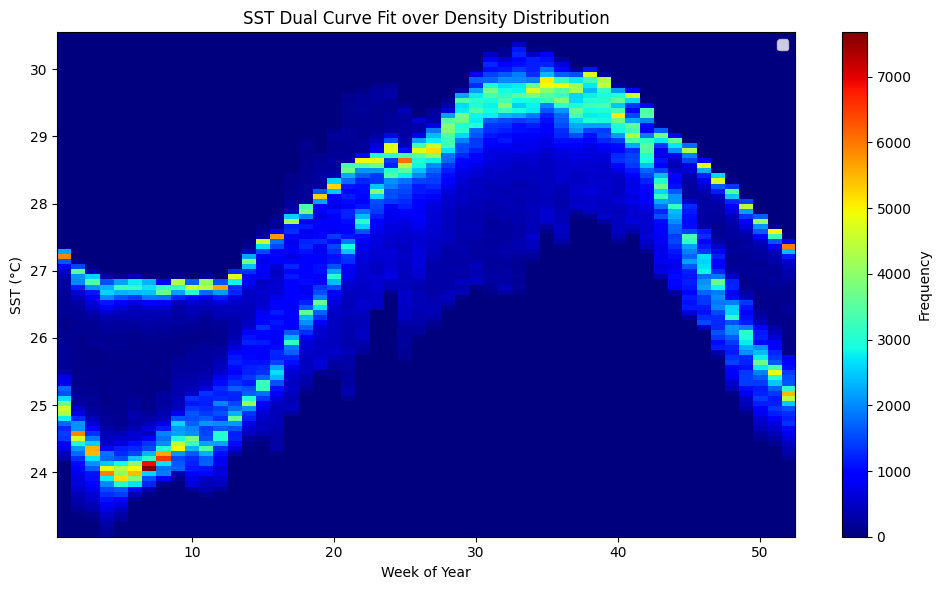

In [7]:
# Plot Results
plt.figure(figsize=(10, 6))

# Plot SST Density Map (2D Histogram) instead of point cloud
plt.imshow(h_sst.T, origin='lower', aspect='auto', 
           extent=[0.5, 52.5, y_sst.min(), y_sst.max()], 
           cmap='jet')
plt.colorbar(label='Frequency')

x_plot = np.linspace(1, 52, 200)

phase = 3.75
                                    # A, phase, offset
#plt.plot(x_plot, season_curve(x_plot, 2.7, 3.8, 26.9), color='red', lw=3, label='Curve 1')
#plt.plot(x_plot, season_curve(x_plot, 1.5, 3.7, 28.2), color='red', lw=3, label='Curve 2')

plt.title("SST Dual Curve Fit over Density Distribution")
plt.xlabel("Week of Year")
plt.ylabel("SST (°C)")

plt.legend()
plt.tight_layout()
plt.show()

## SSL: Nonlinear Least Squares with Nearest-Neighbor Loss (Three Curves)
We fit three seasonal curves simultaneously by minimizing the distance of every data point to the *closest* of the three curves, avoiding the noise associated with tracking individual peaks.

In [8]:
df_ssl = weekly_data['ssl']
h_ssl, x_ssl, y_ssl = get_density_map(df_ssl, y_bins_count=150)

# Extract raw points from the dataframe to fit easily
weeks_ssl_raw = df_ssl['week'].values
ssl_raw = df_ssl['value'].values

def nearest_neighbor_loss_3(params, x, y):
    # Param layout: A1, p1, o1, A2, p2, o2, A3, p3, o3
    A1, p1, o1, A2, p2, o2, A3, p3, o3 = params
    
    y_pred1 = season_curve(x, A1, p1, o1)
    y_pred2 = season_curve(x, A2, p2, o2)
    y_pred3 = season_curve(x, A3, p3, o3)
    
    # Squared error to each curve
    err1 = (y - y_pred1)**2
    err2 = (y - y_pred2)**2
    err3 = (y - y_pred3)**2
    
    # Take the minimum error for each point (nearest neighbor assigned)
    min_err = np.minimum(np.minimum(err1, err2), err3)
    return np.sum(min_err)

# Initial Guesses for the three curves based on visual density distribution
initial_guess_ssl = [
    0.1, 0.0, 0.65,  # Curve 1 (Top Band)
    0.1, 0.0, 0.45,  # Curve 2 (Middle Band)
    0.1, 0.0, 0.25   # Curve 3 (Bottom Band)
]

print("Fitting 3 SSL curves...")
res_ssl = minimize(nearest_neighbor_loss_3, initial_guess_ssl, args=(weeks_ssl_raw, ssl_raw), method='Nelder-Mead')
opt_params_ssl = res_ssl.x
print("Optimization Status:", res_ssl.message)

Fitting 3 SSL curves...


KeyboardInterrupt: 

NameError: name 'opt_params_ssl' is not defined

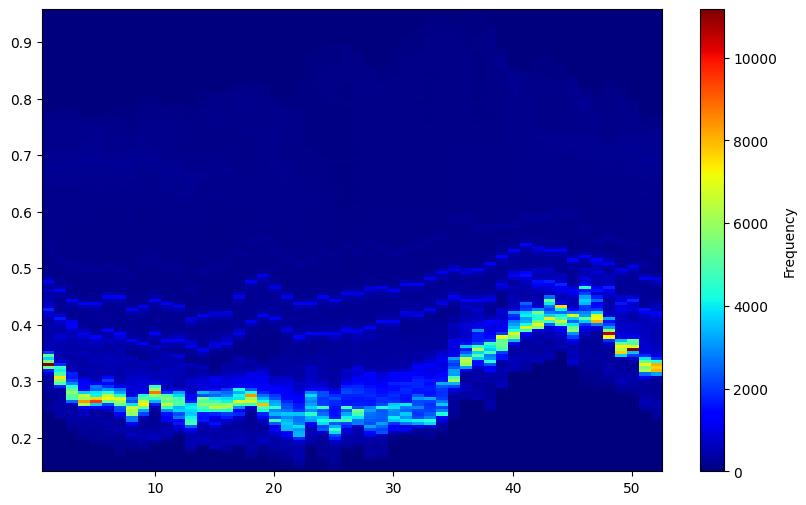

In [ ]:
# Plot Results
plt.figure(figsize=(10, 6))

# Use h_ssl directly to show true data without normalization/log transforms
plt.imshow(h_ssl.T, origin='lower', aspect='auto', 
           extent=[0.5, 52.5, y_ssl.min(), y_ssl.max()], 
           cmap='jet')
plt.colorbar(label='Frequency')

x_plot = np.linspace(1, 52, 200)

plt.plot(x_plot, season_curve(x_plot, *opt_params_ssl[:3]), color='red', lw=3, label='Curve 1 (Top Band)')
plt.plot(x_plot, season_curve(x_plot, *opt_params_ssl[3:6]), color='red', lw=3, label='Curve 2 (Mid Band)')
plt.plot(x_plot, season_curve(x_plot, *opt_params_ssl[6:]), color='red', lw=3, label='Curve 3 (Bottom Band)')

plt.title("SSL Ridge Lines & Harmonic Fits over Density Distribution (True Data)")
plt.xlabel("Week of Year")
plt.ylabel("SSL (m)")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Calculate weekly mean and stdev for SST
week_stats = df_sst.groupby('week')['value'].agg(['mean', 'std']).reset_index()
week_stats['threshold'] = week_stats['mean'] - week_stats['std']

plt.figure(figsize=(10, 6))

# Plot full density map in muted colors (e.g., bone or simply with low alpha)
plt.imshow(h_sst.T, origin='lower', aspect='auto', 
           extent=[0.5, 52.5, y_sst.min(), y_sst.max()], 
           cmap='bone_r', alpha=0.3)

# Create a highlighted histogram for values <= threshold
h_highlight = np.zeros_like(h_sst)
for i, week in enumerate(range(1, 53)):
    thresh = week_stats.loc[week_stats['week'] == week, 'threshold']
    if not thresh.empty:
        thresh_val = thresh.values[0]
        y_mask = y_sst <= thresh_val
        h_highlight[i, y_mask] = h_sst[i, y_mask]

# Mask zeros so they are transparent
h_highlight_masked = np.ma.masked_where(h_highlight == 0, h_highlight)

# Plot highlighted part in color
cax = plt.imshow(h_highlight_masked.T, origin='lower', aspect='auto', 
                 extent=[0.5, 52.5, y_sst.min(), y_sst.max()], 
                 cmap='jet')
plt.colorbar(cax, label=r'Frequency (Region $\mathbf{\leq} -1\sigma$)')

# Plot the threshold line
plt.plot(week_stats['week'], week_stats['threshold'], color='red', lw=2, linestyle='--', label=r'$-1\sigma$ Threshold')
plt.plot(week_stats['week'], week_stats['mean'], color='black', lw=2, linestyle='-', label='Mean')

plt.title(r"SST Density Distribution: Highlighting Upwelling Range ($\mathbf{\leq} -1\sigma$)")
plt.xlabel("Week of Year")
plt.ylabel("SST (°C)")
plt.legend()
plt.tight_layout()
plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Makai\AppData\Local\Temp\ipykernel_81480\4275510615.py:28: SyntaxWarning: invalid escape sequence '\m'
  plt.colorbar(cax, label='Frequency (Region $\mathbf{\leq} -1\sigma$)')
C:\Users\Makai\AppData\Local\Temp\ipykernel_81480\4275510615.py:31: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(week_stats['week'], week_stats['threshold'], color='red', lw=2, linestyle='--', label='$-1\sigma$ Threshold')
C:\Users\Makai\AppData\Local\Temp\ipykernel_81480\4275510615.py:34: SyntaxWarning: invalid escape sequence '\m'
  plt.title("SST Density Distribution: Highlighting Upwelling Range ($\mathbf{\leq} -1\sigma$)")


NameError: name 'df_sst' is not defined